       chrom    startbp      endbp                   x1                   x2  \
21272  chr14  101235000  101425000  0.25160378221498275  0.25160378221498275   
21276  chr14  106005000  106070000   0.1413055016503292   0.1413055016503292   
21292  chr14  100440000  100645000    0.528078545180723    0.528078545180723   
21298  chr14  104015000  104485000   0.1356702577041052   0.1356702577041052   
21311  chr14  101790000  101945000   0.4686299342310997   0.4686299342310997   
21364  chr14  103335000  103390000   0.6081529581529582   0.6081529581529582   
21414  chr14  103570000  103625000    0.258125836045544    0.258125836045544   
21444  chr14  102215000  102315000   0.5437300810162143   0.5437300810162143   
21445  chr14  102140000  102315000   0.5468587399846442   0.5515194917844372   
21458  chr14  106110000  106215000   0.3703277739261974   0.3703277739261974   
21471  chr14  105945000  106070000  0.21990663111778982   0.2360454695927597   
21506  chr14  106420000  106555000  0.36

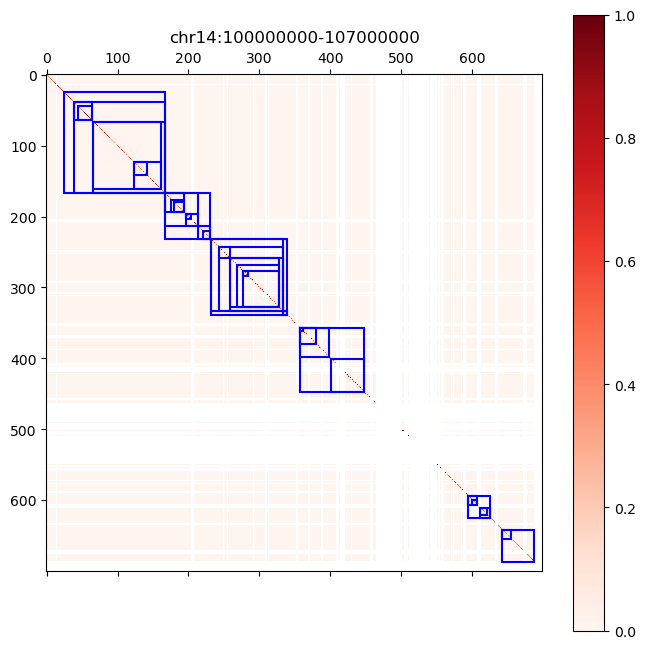

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import cooler

# Load TADs and Cooler matrix
tads = pd.read_csv('/usr/users/papantonis1/RobusTAD/final_tad_ctrl_all.bed', 
                   sep='\t', header=None, comment='#', names=['chrom', 'startbp', 'endbp', 'x1', 'x2', 'left_score', 'right_score'],
                   dtype={'chrom': str, 'startbp': str, 'endbp': str})

# Filter numeric rows only
tads = tads[pd.to_numeric(tads['startbp'], errors='coerce').notna()]
tads['startbp'] = tads['startbp'].astype(int)
tads['endbp'] = tads['endbp'].astype(int)

clr = cooler.Cooler("/usr/users/papantonis1/aman/microc_data/nadine_macro/ctrl-MNase-R1-filtered.mcool::resolutions/10000")

# Define region and resolution
chrom = 'chr14'
start = 100_000_000
end = 107_000_000
resolution = 10000

# Extract matrix
mat = clr.matrix(balance=True).fetch(f"{chrom}:{start}-{end}")

# Plot matrix
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.matshow(mat, cmap='Reds', vmax=1.0)

visible_tads = tads.query('chrom == @chrom and startbp >= @start and endbp <= @end')
print(visible_tads)


# Overlay TADs (filtered for region)
for _, row in tads.query('chrom == @chrom and startbp >= @start and endbp <= @end').iterrows():
    start_bin = (row['startbp'] - start) // resolution
    end_bin = (row['endbp'] - start) // resolution
    ax.add_patch(plt.Rectangle((start_bin, start_bin), end_bin - start_bin, end_bin - start_bin,
                               edgecolor='blue', fill=False, linewidth=1.5))

plt.title(f"{chrom}:{start}-{end}")
plt.colorbar(im)
plt.show()

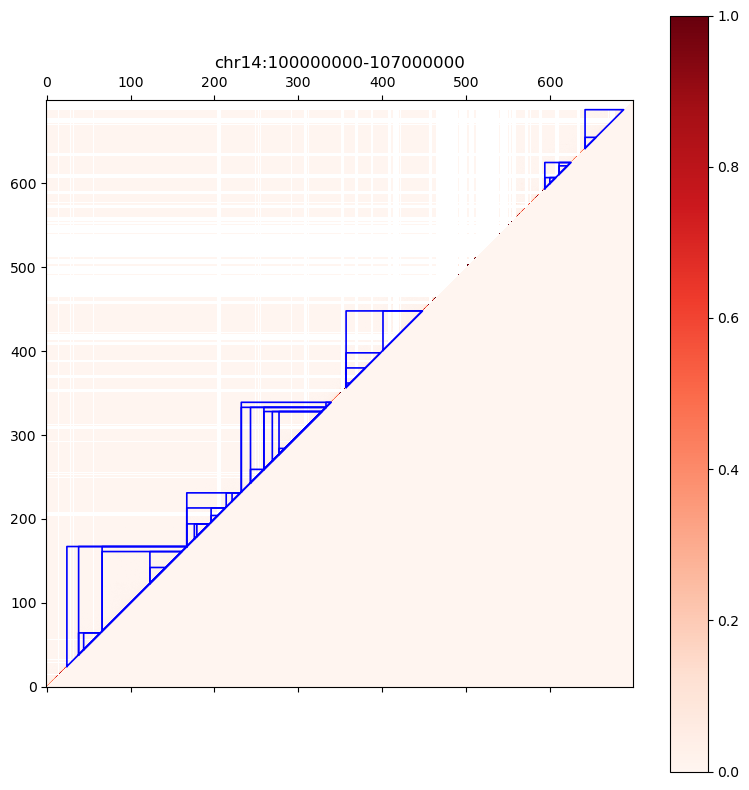

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cooler

# Load TADs and Cooler matrix
tads = pd.read_csv('/usr/users/papantonis1/RobusTAD/final_tad_ctrl_all.bed', 
                   sep='\t', header=None, comment='#', 
                   names=['chrom', 'startbp', 'endbp', 'x1', 'x2', 'left_score', 'right_score'],
                   dtype={'chrom': str, 'startbp': str, 'endbp': str})

# Filter numeric rows only and cast to int
tads = tads[pd.to_numeric(tads['startbp'], errors='coerce').notna()]
tads['startbp'] = tads['startbp'].astype(int)
tads['endbp'] = tads['endbp'].astype(int)

# Load Cooler file
clr = cooler.Cooler("/usr/users/papantonis1/aman/microc_data/nadine_macro/ctrl-MNase-R1-filtered.mcool::resolutions/10000")

# Set region and resolution
chrom = 'chr14'
start = 100_000_000
end = 107_000_000
resolution = 10_000

# Extract matrix
mat = clr.matrix(balance=True).fetch(f"{chrom}:{start}-{end}")
mat = np.tril(mat)  # lower triangle for triangular Hi-C

# Plot matrix
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.matshow(mat, cmap='Reds', vmax=1.0)
plt.gca().invert_yaxis()

# Filter TADs in this region
visible_tads = tads.query('chrom == @chrom and startbp >= @start and endbp <= @end')

# Overlay triangle TADs
for _, row in visible_tads.iterrows():
    start_bin = (row['startbp'] - start) // resolution
    end_bin = (row['endbp'] - start) // resolution

    # Triangle corners: left, right, top
    x = [start_bin, end_bin, start_bin]
    y = [start_bin, end_bin, end_bin]

    # Close triangle path
    ax.plot(x + [x[0]], y + [y[0]], color='blue', linewidth=1.2)

# Finalize plot
plt.title(f"{chrom}:{start}-{end}")
plt.colorbar(im)
plt.tight_layout()
plt.show()

In [9]:
clr.chromsizes

name
chr1     248956422
chr2     242193529
chr3     198295559
chr4     190214555
chr5     181538259
chr6     170805979
chr7     159345973
chr8     145138636
chr9     138394717
chr10    133797422
chr11    135086622
chr12    133275309
chr13    114364328
chr14    107043718
chr15    101991189
chr16     90338345
chr17     83257441
chr18     80373285
chr19     58617616
chr20     64444167
chr21     46709983
chr22     50818468
chrX     156040895
chrY      57227415
chrM         16569
Name: length, dtype: int32